In [2]:
## 셀 1: E축에 IDW_mean 추가 (팀원 데이터 반영)

import pandas as pd
import geopandas as gpd

df = pd.read_csv('grid_HSI_selected_indicators.csv')
idw = gpd.read_file('Grid_IDW_mean_max_FINAL.gpkg')[['grid_id', 'Grid_IDW_mean_sample_SAMPLE_1']]
idw = idw.rename(columns={'Grid_IDW_mean_sample_SAMPLE_1': 'IDW_mean'})

df = pd.merge(df, idw, on='grid_id', how='left')

print("merge 후 행 수:", len(df))
print("merge 후 컬럼 수:", len(df.columns))
print("IDW_mean 결측치:", df['IDW_mean'].isna().sum())
print()
print(df['IDW_mean'].describe())

merge 후 행 수: 11388
merge 후 컬럼 수: 23
IDW_mean 결측치: 0

count    11388.000000
mean        29.925431
std          0.319143
min         29.144041
25%         29.727045
50%         29.895269
75%         30.162502
max         30.579573
Name: IDW_mean, dtype: float64


In [3]:
## 셀 2: grid_HSI_selected_indicators_v2 저장

df.to_csv('grid_HSI_selected_indicators_v2.csv', index=False, encoding='utf-8-sig')

print("저장 완료: grid_HSI_selected_indicators_v2.csv")
print(f"행 수: {len(df):,}개, 컬럼 수: {len(df.columns)}개")

저장 완료: grid_HSI_selected_indicators_v2.csv
행 수: 11,388개, 컬럼 수: 23개


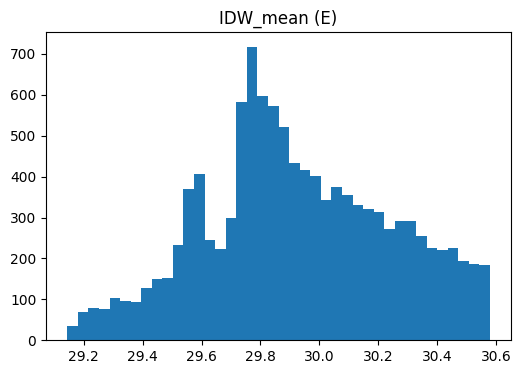

In [4]:
## 셀 3: IDW_mean 히스토그램

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(df['IDW_mean'].dropna(), bins=40)
plt.title('IDW_mean (E)')
plt.show()

In [5]:
## 셀 4: E축 표준화 (LST + IDW_mean)

import pandas as pd
import numpy as np

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

e_std = pd.DataFrame(index=df.index)
e_std['LST_C_mean_5scene'] = minmax(df['LST_C_mean_5scene'])
e_std['IDW_mean'] = minmax(df['IDW_mean'])

# LST 결측치(구름마스킹) 처리 - 전체 평균으로 대체
e_mean = e_std['LST_C_mean_5scene'].mean()
e_std['LST_C_mean_5scene'] = e_std['LST_C_mean_5scene'].fillna(e_mean)

print("=== E축 표준화 결과 ===")
print(e_std.describe())
print()
print("결측치:", e_std.isna().sum().sum())

=== E축 표준화 결과 ===
       LST_C_mean_5scene      IDW_mean
count       11388.000000  11388.000000
mean            0.335521      0.544321
std             0.108548      0.222317
min             0.000000      0.000000
25%             0.283819      0.406124
50%             0.342794      0.523310
75%             0.406561      0.709466
max             1.000000      1.000000

결측치: 0


In [6]:
## 셀 5: 표준화 v2 저장 (E축 업데이트 반영)

df_stage10 = pd.read_csv('grid_HSI_standardized_stage10.csv')

meta_cols = ['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat']
s_cols = ['LC1_100_시가화건조지역_ratio', 'pop_peak_h', 'pop_elderl', 'pop_lunch_', 'daycare_cnt', 'senior_facility_total']
a_cols = ['NDVI_mean_5scene', 'GREEN_ratio_LC', 'adaptive_facility_total', 'tree_road_len']

meta_keep = df_stage10[meta_cols]
s_std_v2 = df_stage10[s_cols]
a_std_v2 = df_stage10[a_cols]

df_standardized_v2 = pd.concat([meta_keep, e_std, s_std_v2, a_std_v2], axis=1)

df_standardized_v2.to_csv('grid_HSI_standardized_stage10_v2.csv', index=False, encoding='utf-8-sig')

print("저장 완료: grid_HSI_standardized_stage10_v2.csv")
print(f"행 수: {len(df_standardized_v2):,}개, 컬럼 수: {len(df_standardized_v2.columns)}개")
print()
print("E축:", e_std.columns.tolist())
print("S축:", s_std_v2.columns.tolist())
print("A축:", a_std_v2.columns.tolist())

저장 완료: grid_HSI_standardized_stage10_v2.csv
행 수: 11,388개, 컬럼 수: 20개

E축: ['LST_C_mean_5scene', 'IDW_mean']
S축: ['LC1_100_시가화건조지역_ratio', 'pop_peak_h', 'pop_elderl', 'pop_lunch_', 'daycare_cnt', 'senior_facility_total']
A축: ['NDVI_mean_5scene', 'GREEN_ratio_LC', 'adaptive_facility_total', 'tree_road_len']


In [7]:
## 셀 6: E/S/A 축별 PCA (부호보정 포함)

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

def minmax_eps(s, eps=0.01):
    m = (s - s.min()) / (s.max() - s.min() + 1e-9)
    return m * (1 - eps) + eps  # [eps, 1] 범위로 강제

def run_axis_pca(std_df, axis_name, expect_positive=True):
    """
    std_df: 해당 축의 표준화된 지표들 (0~1)
    expect_positive: True면 '지표가 높을수록 축 점수도 높아야 함' 가정하에 부호 보정
    """
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(std_df.fillna(0)).flatten()

    loadings = pca.components_[0]
    print(f"\n[{axis_name}] PC1 설명분산비: {pca.explained_variance_ratio_[0]:.3f}")
    print(f"[{axis_name}] 적재값(loading):")
    for col, load in zip(std_df.columns, loadings):
        print(f"  {col}: {load:.3f}")

    # 부호보정: 적재값 평균이 음수면 전체 부호 반전
    if loadings.mean() < 0:
        pc1 = -pc1
        print(f"[{axis_name}] 부호 반전 적용됨 (적재값 평균이 음수였음)")

    pc1_series = pd.Series(pc1, index=std_df.index)
    # 부호보정 먼저 끝난 뒤에 Min-Max (epsilon 포함)
    score = minmax_eps(pc1_series)
    return score, pca.explained_variance_ratio_[0]

e_score, e_var = run_axis_pca(e_std, 'E축')
s_score, s_var = run_axis_pca(s_std_v2, 'S축')
a_score, a_var = run_axis_pca(a_std_v2, 'A축')

print("\n=== 축 스코어 요약 ===")
print("E_score:", e_score.describe())
print("\nS_score:", s_score.describe())
print("\nA_score:", a_score.describe())


[E축] PC1 설명분산비: 0.808
[E축] 적재값(loading):
  LST_C_mean_5scene: 0.028
  IDW_mean: -1.000
[E축] 부호 반전 적용됨 (적재값 평균이 음수였음)

[S축] PC1 설명분산비: 0.713
[S축] 적재값(loading):
  LC1_100_시가화건조지역_ratio: 0.918
  pop_peak_h: 0.190
  pop_elderl: 0.300
  pop_lunch_: 0.173
  daycare_cnt: 0.003
  senior_facility_total: 0.005

[A축] PC1 설명분산비: 0.663
[A축] 적재값(loading):
  NDVI_mean_5scene: 0.425
  GREEN_ratio_LC: 0.893
  adaptive_facility_total: -0.017
  tree_road_len: -0.147

=== 축 스코어 요약 ===
E_score: count    11388.000000
mean         0.552455
std          0.220112
min          0.010000
25%          0.414356
50%          0.530679
75%          0.716009
max          1.000000
dtype: float64

S_score: count    11388.000000
mean         0.430101
std          0.242567
min          0.010000
25%          0.226750
50%          0.462819
75%          0.633287
max          1.000000
dtype: float64

A_score: count    11388.000000
mean         0.451148
std          0.284012
min          0.010000
25%          0.201419
50%     

In [8]:
## 셀 7: E축 재계산 (단순평균) + epsilon 통일

def minmax_eps(s, eps=0.01):
    m = (s - s.min()) / (s.max() - s.min() + 1e-9)
    return m * (1 - eps) + eps

# E축: PCA 대신 단순평균 (지표 2개, 상관계수 0.09로 독립적 -> PCA 압축 이점 없음)
e_score_raw = (e_std['LST_C_mean_5scene'] + e_std['IDW_mean']) / 2
e_score = minmax_eps(e_score_raw)

print("=== E_score (단순평균 기반) ===")
print(e_score.describe())

=== E_score (단순평균 기반) ===
count    11388.000000
mean         0.469800
std          0.187792
min          0.010000
25%          0.332389
50%          0.465046
75%          0.600971
max          1.000000
dtype: float64


In [9]:
## 셀 8: 엔트로피 가중치 계산

import numpy as np
import pandas as pd

axis_df = pd.DataFrame({
    'E': e_score,
    'S': s_score,
    'A': a_score
})

n = len(axis_df)
k = 1 / np.log(n)

# 1단계: 비율로 정규화
p = axis_df / axis_df.sum(axis=0)

# 2단계: 엔트로피 계산 (0*log(0)=0 방어)
def safe_plogp(p_col):
    return np.where(p_col == 0, 0, p_col * np.log(p_col))

entropy = -k * p.apply(safe_plogp).sum(axis=0)

# 3단계: 가중치 변환
diversity = 1 - entropy
weights = diversity / diversity.sum()

print("=== 엔트로피 계산 결과 ===")
print("엔트로피 (e_j):")
print(entropy)
print()
print("다양성 (d_j = 1-e_j):")
print(diversity)
print()
print("=== 최종 가중치 ===")
print(weights)

=== 엔트로피 계산 결과 ===
엔트로피 (e_j):
E    0.990908
S    0.979080
A    0.979019
dtype: float64

다양성 (d_j = 1-e_j):
E    0.009092
S    0.020920
A    0.020981
dtype: float64

=== 최종 가중치 ===
E    0.178291
S    0.410262
A    0.411446
dtype: float64


In [11]:
## 셀 10: CRITIC법 가중치 계산

import numpy as np
import pandas as pd

axis_df = pd.DataFrame({
    'E': e_score,
    'S': s_score,
    'A': a_score
})

# 표준편차
std = axis_df.std()

# 상관계수 행렬
corr = axis_df.corr()

print("=== 표준편차 ===")
print(std)
print()
print("=== 상관계수 행렬 ===")
print(corr)

# C_j = std_j * sum(1 - r_jk)  for all k
C = pd.Series(index=axis_df.columns, dtype=float)
for j in axis_df.columns:
    conflict = sum(1 - corr.loc[j, k] for k in axis_df.columns)
    C[j] = std[j] * conflict

weights_critic = C / C.sum()

print("\n=== CRITIC 정보량(C_j) ===")
print(C)
print()
print("=== CRITIC 가중치 ===")
print(weights_critic)

print("\n=== 엔트로피 vs CRITIC 비교 ===")
comparison = pd.DataFrame({'엔트로피': weights, 'CRITIC': weights_critic})
print(comparison)

=== 표준편차 ===
E    0.187792
S    0.242567
A    0.284012
dtype: float64

=== 상관계수 행렬 ===
          E         S         A
E  1.000000  0.321416 -0.338001
S  0.321416  1.000000 -0.862866
A -0.338001 -0.862866  1.000000

=== CRITIC 정보량(C_j) ===
E    0.378699
S    0.616473
A    0.909083
dtype: float64

=== CRITIC 가중치 ===
E    0.198870
S    0.323735
A    0.477396
dtype: float64

=== 엔트로피 vs CRITIC 비교 ===
       엔트로피    CRITIC
E  0.178291  0.198870
S  0.410262  0.323735
A  0.411446  0.477396


In [12]:
## 셀 11: HSI 계산 (덧셈식) + 재정규화

wE, wS, wA = weights['E'], weights['S'], weights['A']

HSI_raw = wE * e_score + wS * s_score - wA * a_score

print("=== HSI_raw (재정규화 전) ===")
print(HSI_raw.describe())

HSI = (HSI_raw - HSI_raw.min()) / (HSI_raw.max() - HSI_raw.min())

print("\n=== HSI (0~1 재정규화 후) ===")
print(HSI.describe())

=== HSI_raw (재정규화 전) ===
count    11388.000000
mean         0.074592
std          0.222565
min         -0.392866
25%         -0.066585
50%          0.111275
75%          0.257763
max          0.527444
dtype: float64

=== HSI (0~1 재정규화 후) ===
count    11388.000000
mean         0.507936
std          0.241837
min          0.000000
25%          0.354535
50%          0.547795
75%          0.706968
max          1.000000
dtype: float64


In [18]:
## 셀 12 (대안): KMeans 기반 Jenks 근사 (빠른 버전)

from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

X = HSI.values.reshape(-1, 1)
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km.fit_predict(X)

# 클러스터 중심값 기준으로 정렬해서 1~5등급 부여 (값이 낮은 클러스터=1등급)
centers = km.cluster_centers_.flatten()
order = np.argsort(centers)
label_map = {old: new+1 for new, old in enumerate(order)}
HSI_grade_jenks = pd.Series(labels).map(label_map)

print("=== 등급별 격자 개수 ===")
print(HSI_grade_jenks.value_counts().sort_index())

print("\n=== 등급별 비율(%) ===")
print((HSI_grade_jenks.value_counts(normalize=True).sort_index() * 100).round(2))

print("\n=== 등급별 HSI 범위 ===")
for g in sorted(HSI_grade_jenks.unique()):
    vals = HSI[HSI_grade_jenks == g]
    print(f"{g}등급: {vals.min():.4f} ~ {vals.max():.4f}")

=== 등급별 격자 개수 ===
1    1847
2    1706
3    2688
4    2612
5    2535
Name: count, dtype: int64

=== 등급별 비율(%) ===
1    16.22
2    14.98
3    23.60
4    22.94
5    22.26
Name: proportion, dtype: float64

=== 등급별 HSI 범위 ===
1등급: 0.0000 ~ 0.2100
2등급: 0.2100 ~ 0.4174
3등급: 0.4175 ~ 0.5768
4등급: 0.5770 ~ 0.7209
5등급: 0.7210 ~ 1.0000


In [20]:
## 셀 13: 최종 HSI 결과 저장

import pandas as pd

meta_cols = ['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat']
meta_keep = df_stage10[meta_cols]

df_hsi_final = meta_keep.copy()
df_hsi_final['E_score'] = e_score
df_hsi_final['S_score'] = s_score
df_hsi_final['A_score'] = a_score
df_hsi_final['HSI'] = HSI
df_hsi_final['HSI_grade'] = HSI_grade_jenks

df_hsi_final.to_csv('grid_HSI_final_result.csv', index=False, encoding='utf-8-sig')

print("저장 완료: grid_HSI_final_result.csv")
print(f"행 수: {len(df_hsi_final):,}개, 컬럼 수: {len(df_hsi_final.columns)}개")
print(df_hsi_final.columns.tolist())

저장 완료: grid_HSI_final_result.csv
행 수: 11,388개, 컬럼 수: 13개
['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat', 'E_score', 'S_score', 'A_score', 'HSI', 'HSI_grade']


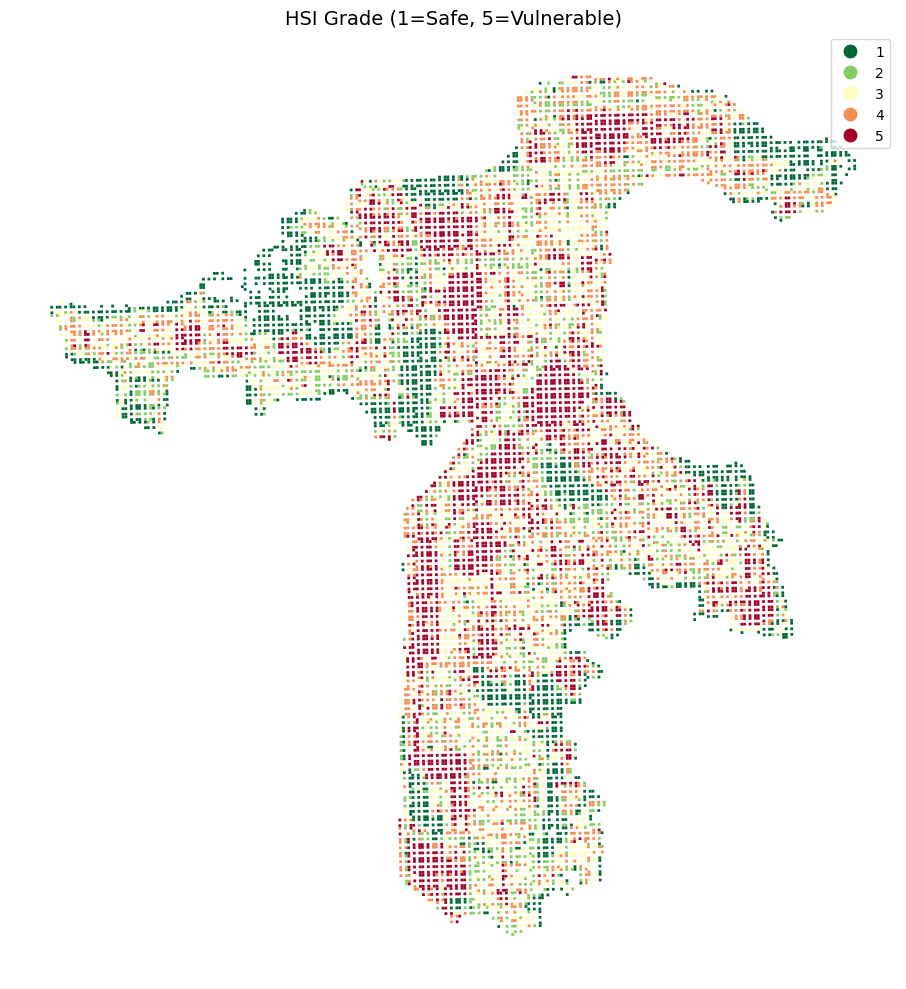

In [21]:
## 셀 14: HSI 등급 지도 시각화

import geopandas as gpd
import matplotlib.pyplot as plt

# geometry가 WKT 문자열이면 변환 필요
if df_hsi_final['geometry'].dtype == object:
    from shapely import wkt
    df_hsi_final['geometry'] = df_hsi_final['geometry'].apply(
        lambda x: wkt.loads(x) if isinstance(x, str) else x
    )

gdf_hsi = gpd.GeoDataFrame(df_hsi_final, geometry='geometry', crs='EPSG:4326')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_hsi.plot(
    column='HSI_grade',
    categorical=True,
    cmap='RdYlGn_r',   # 초록(안전)~빨강(취약)
    legend=True,
    ax=ax,
    edgecolor='none'
)
ax.set_title('HSI Grade (1=Safe, 5=Vulnerable)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [23]:
## 대안: folium으로 배경지도 위에 HSI 등급 표시

import folium

center_lat = gdf_hsi.geometry.centroid.y.mean()
center_lon = gdf_hsi.geometry.centroid.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='cartodbpositron')

color_map = {1: '#1a9850', 2: '#91cf60', 3: '#ffffbf', 4: '#fc8d59', 5: '#d73027'}

folium.GeoJson(
    gdf_hsi,
    style_function=lambda feature: {
        'fillColor': color_map[feature['properties']['HSI_grade']],
        'color': 'none',
        'fillOpacity': 0.6,
    }
).add_to(m)

m

/tmp/ipykernel_77/1213088085.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = gdf_hsi.geometry.centroid.y.mean()
/tmp/ipykernel_77/1213088085.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = gdf_hsi.geometry.centroid.x.mean()


In [24]:
## 셀 16: folium 레이어 토글로 HSI/E/S/A 비교

import folium
import matplotlib.cm as cm
import matplotlib.colors as mcolors

center_lat = gdf_hsi.geometry.centroid.y.mean()
center_lon = gdf_hsi.geometry.centroid.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='cartodbpositron')

def add_score_layer(gdf, column, layer_name, cmap_name='RdYlGn_r', show=False):
    norm = mcolors.Normalize(vmin=gdf[column].min(), vmax=gdf[column].max())
    cmap = cm.get_cmap(cmap_name)

    fg = folium.FeatureGroup(name=layer_name, show=show)

    for _, row in gdf.iterrows():
        color = mcolors.to_hex(cmap(norm(row[column])))
        folium.GeoJson(
            row['geometry'],
            style_function=lambda x, color=color: {
                'fillColor': color,
                'color': 'none',
                'fillOpacity': 0.6,
            },
            tooltip=f"{layer_name}: {row[column]:.3f}"
        ).add_to(fg)

    fg.add_to(m)

# 4개 레이어 추가 (HSI만 기본으로 켜짐)
add_score_layer(gdf_hsi, 'HSI', 'HSI (종합)', show=True)
add_score_layer(gdf_hsi, 'E_score', 'E축 (노출)', show=False)
add_score_layer(gdf_hsi, 'S_score', 'S축 (민감도)', show=False)
add_score_layer(gdf_hsi, 'A_score', 'A축 (적응역량)', show=False)

folium.LayerControl(collapsed=False).add_to(m)

m

/tmp/ipykernel_77/488323197.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = gdf_hsi.geometry.centroid.y.mean()
/tmp/ipykernel_77/488323197.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = gdf_hsi.geometry.centroid.x.mean()
/tmp/ipykernel_77/488323197.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name)
